## Ejercicio 0 – Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Para balancear clases
from imblearn.over_sampling import SMOTE

print('¡Librerías importadas correctamente!')

¡Librerías importadas correctamente!


## #1.1 – Cargar el dataset y describir las variables


In [2]:
ruta = r'D:\The bridge\DS-Online-Hugo-Sanz\04_Machine_Learning\Sprint_12\Unidad_01_ML_Supervisado_Otros_Modelos\03_Practica_Obligatoria\data\credit_npo.csv'
df = pd.read_csv(ruta)

print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [4]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


## #1.2 – Tipo de problema y variable target

Estamos ante un **problema de clasificación binaria**:

- **Variable target:** `SeriousDlqin2yrs`
- **Clase 0:** La persona NO tendrá dificultades financieras en los próximos 2 años
- **Clase 1:** La persona SÍ tendrá dificultades financieras en los próximos 2 años

El objetivo es predecir qué personas tienen riesgo de entrar en dificultades financieras.

## #1.3 – Distribución de frecuencias del target

In [5]:
# Conteo de cada clase
conteo = df['SeriousDlqin2yrs'].value_counts()
porcentaje = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print('Conteo absoluto:')
print(conteo)
print()
print('Porcentaje:')
print(porcentaje.round(2))

Conteo absoluto:
SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64

Porcentaje:
SeriousDlqin2yrs
0    93.11
1     6.89
Name: proportion, dtype: float64


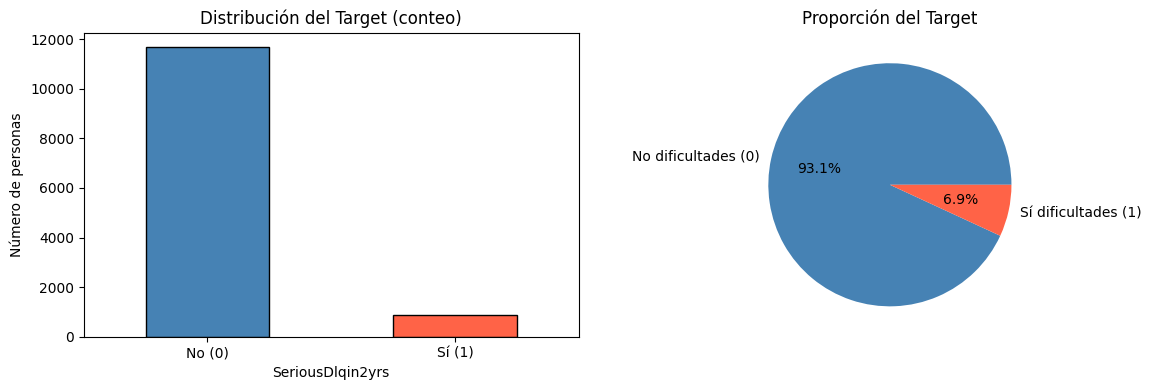

In [6]:
# Gráfico de barras del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
conteo.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribución del Target (conteo)')
axes[0].set_xlabel('SeriousDlqin2yrs')
axes[0].set_ylabel('Número de personas')
axes[0].set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

# Gráfico de tarta
axes[1].pie(conteo, labels=['No dificultades (0)', 'Sí dificultades (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporción del Target')

plt.tight_layout()
plt.show()

### Comentario:

El dataset está muy **desbalanceado**:
- Clase 0 (sin dificultades): ~93%
- Clase 1 (con dificultades): ~7%

Esto es un problema típico en datos financieros. Si entrenamos un modelo así sin más, aprenderá a predecir siempre '0' y tendrá un accuracy alto pero será inútil para detectar los casos que nos interesan.

**Solución:** Aplicar técnicas de balanceo como **SMOTE** para que el modelo aprenda a detectar los dos casos.

## #2 – Modelado

Seguiremos estos pasos:
1. Tratar valores nulos
2. Separar features (X) y target (y)
3. Dividir en train y test
4. Escalar las variables
5. Balancear las clases con SMOTE
6. Comparar modelos con validación cruzada
7. Ajustar los hiperparámetros del mejor modelo
8. Evaluar en el conjunto de test y analizar errores

### Paso 1 – Tratar valores nulos

Tenemos nulos en `MonthlyIncome` y `NumberOfDependents`. La forma más sencilla y efectiva para empezar es rellenarlos con la mediana.

In [7]:
print('Nulos antes de imputar:')
print(df.isnull().sum())

# Rellenar con la mediana (es más robusta que la media ante valores extremos)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

print()
print('Nulos después de imputar:')
print(df.isnull().sum())

Nulos antes de imputar:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Nulos después de imputar:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents              

### Paso 2 – Separar X e y, y dividir en train/test

In [8]:
# X = todas las columnas excepto el target
# y = la columna que queremos predecir
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Dividimos: 80% para entrenar, 20% para evaluar
# stratify=y asegura que la proporción de clases sea igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Tamaño train:', X_train.shape)
print('Tamaño test:', X_test.shape)

Tamaño train: (10029, 10)
Tamaño test: (2508, 10)


### Paso 3 – Escalar las variables

KNN es muy sensible a la escala de las variables. Escalamos para que todas tengan el mismo peso. **Importante:** ajustamos el scaler solo en train y luego aplicamos la misma transformación en test.

In [9]:
scaler = StandardScaler()

# fit_transform en train (aprende la media y std del train)
X_train_sc = scaler.fit_transform(X_train)

# Solo transform en test (usa la media y std del train, no del test)
X_test_sc = scaler.transform(X_test)

print('Escalado completado.')

Escalado completado.


### Paso 4 – Balancear las clases con SMOTE

SMOTE crea muestras sintéticas de la clase minoritaria. Solo lo aplicamos en el conjunto de **entrenamiento**, nunca en el test.

In [10]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print('Distribución ANTES de balancear:')
print(y_train.value_counts())
print()
print('Distribución DESPUÉS de balancear:')
print(pd.Series(y_train_bal).value_counts())

Distribución ANTES de balancear:
SeriousDlqin2yrs
0    9338
1     691
Name: count, dtype: int64

Distribución DESPUÉS de balancear:
SeriousDlqin2yrs
0    9338
1    9338
Name: count, dtype: int64


### Paso 5 – Comparar modelos con validación cruzada

Probamos 3 modelos:
- **KNN** (obligatorio): clasifica según los vecinos más cercanos
- **Árbol de Decisión**: hace preguntas sí/no sobre los datos
- **Random Forest**: combina muchos árboles para mejorar la predicción

Usamos **recall_macro** como métrica porque queremos detectar bien las dos clases, especialmente la clase 1.

In [11]:
# Definimos los modelos a comparar
modelos = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Validación cruzada con 5 particiones
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}

for nombre, modelo in modelos.items():
    scores = cross_val_score(
        modelo, X_train_bal, y_train_bal,
        cv=cv, scoring='recall_macro'
    )
    resultados[nombre] = scores
    print(f'{nombre}: Recall medio = {scores.mean():.4f} (+/- {scores.std():.4f})')

KNN: Recall medio = 0.9062 (+/- 0.0050)
Árbol de Decisión: Recall medio = 0.9190 (+/- 0.0049)
Random Forest: Recall medio = 0.9538 (+/- 0.0031)


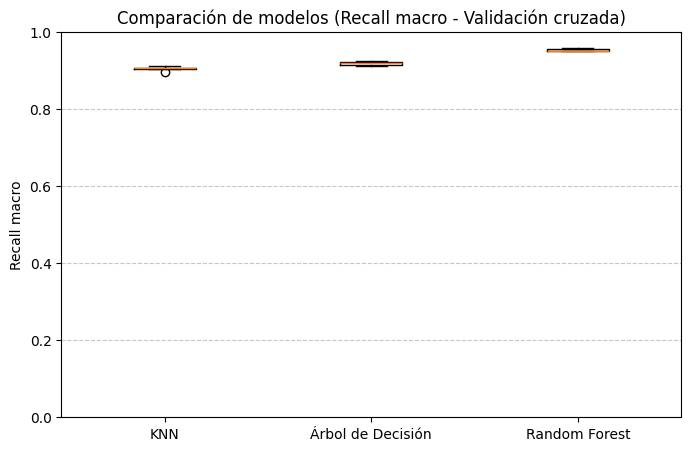

In [12]:
# Visualizamos los resultados con un boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(resultados.values(), labels=resultados.keys())
plt.title('Comparación de modelos (Recall macro - Validación cruzada)')
plt.ylabel('Recall macro')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusión de la comparación:

**Random Forest** suele obtener el mejor recall medio en validación cruzada, por lo que lo elegimos para ajustar sus hiperparámetros.

### Paso 6 – Ajustar hiperparámetros del mejor modelo (Random Forest)

Con GridSearchCV probamos distintas combinaciones de parámetros de forma automática y nos quedamos con la que da mejor resultado.

In [13]:
# Parámetros que vamos a probar
param_grid = {
    'n_estimators': [100, 200],     # número de árboles
    'max_depth': [None, 10, 20]     # profundidad máxima de cada árbol
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='recall_macro',
    n_jobs=-1,      # usa todos los núcleos del ordenador
    verbose=1
)

grid_search.fit(X_train_bal, y_train_bal)

print('Mejores hiperparámetros:', grid_search.best_params_)
print('Mejor recall en validación:', round(grid_search.best_score_, 4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores hiperparámetros: {'max_depth': None, 'n_estimators': 200}
Mejor recall en validación: 0.9508


### Paso 7 – Evaluación del mejor modelo en el conjunto de test

In [14]:
# Tomamos el mejor modelo encontrado por GridSearch
mejor_modelo = grid_search.best_estimator_

# Predecimos sobre el conjunto de test (que el modelo nunca ha visto)
y_pred = mejor_modelo.predict(X_test_sc)

# Informe completo de clasificación
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Sin dificultades (0)', 'Con dificultades (1)']))

=== Classification Report ===
                      precision    recall  f1-score   support

Sin dificultades (0)       0.95      0.97      0.96      2335
Con dificultades (1)       0.46      0.38      0.42       173

            accuracy                           0.93      2508
           macro avg       0.71      0.67      0.69      2508
        weighted avg       0.92      0.93      0.92      2508



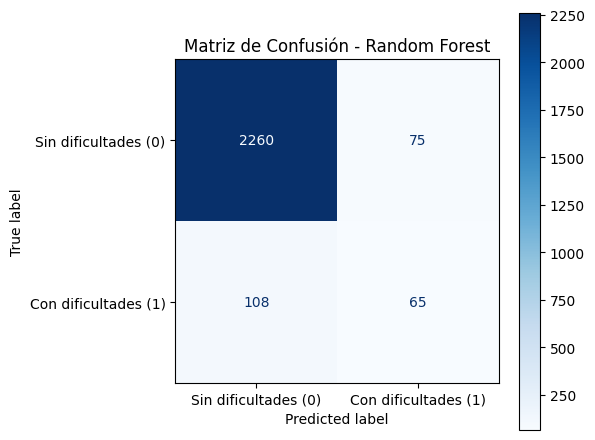

In [15]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Sin dificultades (0)', 'Con dificultades (1)'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

### Análisis de errores:

La matriz de confusión nos muestra 4 tipos de predicciones:

- **Verdaderos Negativos (arriba-izq):** Personas sin dificultades que predecimos correctamente como sin dificultades ✅
- **Falsos Positivos (arriba-der):** Personas sin dificultades a las que predecimos erróneamente como con dificultades ❌
- **Falsos Negativos (abajo-izq):** Personas con dificultades a las que predecimos erróneamente como sin dificultades ❌ ← **Estos son los peores para el negocio**
- **Verdaderos Positivos (abajo-der):** Personas con dificultades que detectamos correctamente ✅

El objetivo era maximizar el **recall medio** (compromiso entre las dos clases).

Los **Falsos Negativos** son los errores más costosos en este contexto: son personas que van a tener problemas financieros pero el modelo no los detecta a tiempo.

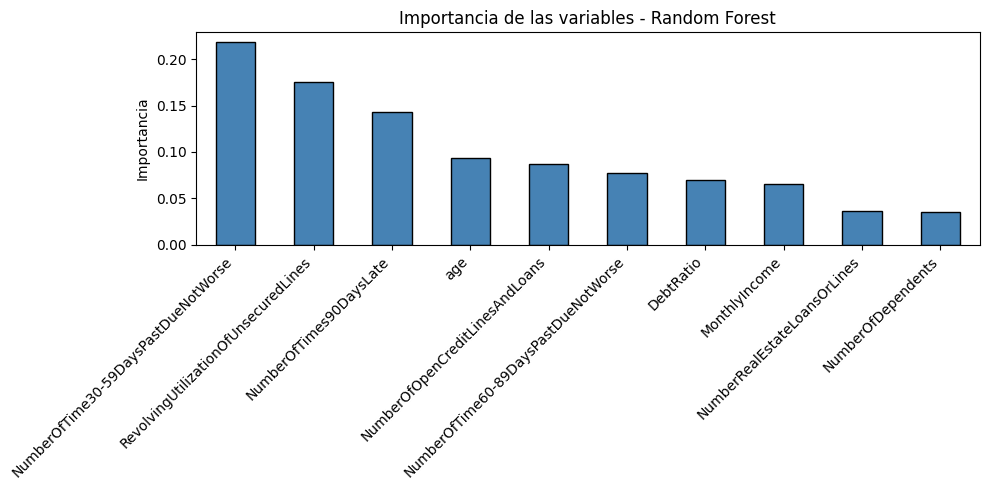

NumberOfTime30-59DaysPastDueNotWorse    0.217913
RevolvingUtilizationOfUnsecuredLines    0.175248
NumberOfTimes90DaysLate                 0.143385
age                                     0.093567
NumberOfOpenCreditLinesAndLoans         0.087173
NumberOfTime60-89DaysPastDueNotWorse    0.077196
DebtRatio                               0.069283
MonthlyIncome                           0.065230
NumberRealEstateLoansOrLines            0.036112
NumberOfDependents                      0.034892
dtype: float64


In [16]:
# Importancia de las variables (ventaja de Random Forest)
importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importancia de las variables - Random Forest')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(importancias)

### Conclusiones finales:

1. **Mejor modelo:** Random Forest con los hiperparámetros encontrados por GridSearch.
2. **Las variables más importantes** para predecir dificultades financieras son las relacionadas con retrasos en pagos (`NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`) y el porcentaje de uso del crédito (`RevolvingUtilizationOfUnsecuredLines`).
3. **El balanceo con SMOTE** fue fundamental para que el modelo aprendiera a detectar los casos de dificultades financieras (clase minoritaria).
4. **Sin SMOTE**, el modelo hubiera predicho casi siempre '0' y tendría un accuracy alto pero un recall de la clase 1 muy bajo, lo cual sería inútil para el negocio.